In [20]:
import pandas as pd
import sklearn
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [21]:
# TASK 1

salary = pd.read_csv("salary.csv")
insurance = pd.read_csv("insurance.csv")
print(salary.shape)
salary.head(5)

# Target is Salary
# YearsExperience is features

(30, 3)


,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [22]:
print(insurance.shape)
insurance.head()
# Target is charges
# Features: children, bmi, age, smoker 

(1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [23]:
# TASK 2

X = salary[['YearsExperience']]
y = salary['Salary']

model = LinearRegression()
model.fit(X,y)

print(f"model intercept: {model.intercept_}")
print(f"model coef: {model.coef_}")

#for every year of experience, salary increases by $9,449.96
#intercept is the salary starter. if 0 years of experience, it defaults to y intercept(for this model).

model intercept: 24848.203966523222
model coef: [9449.96232146]


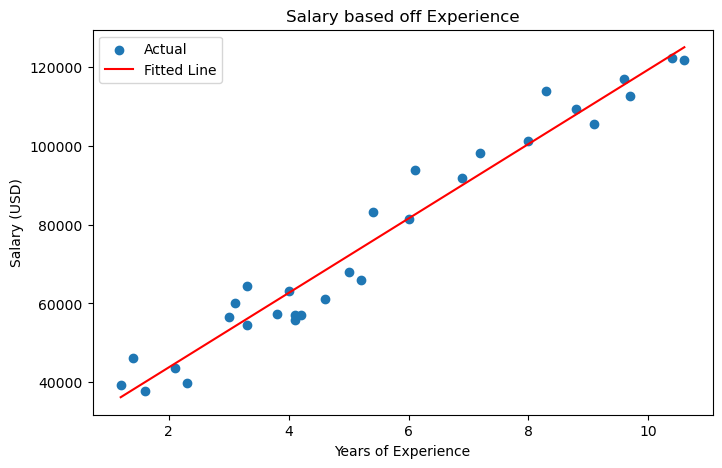

In [24]:
#TASK 3

prediction = model.predict(X)

plt.figure(figsize=(8,5))
plt.scatter(X,y, label='Actual')
plt.plot(X, prediction, color='red', label='Fitted Line')
plt.xlabel("Years of Experience")
plt.ylabel("Salary (USD)")
plt.title("Salary based off Experience")
plt.legend()

plt.tight_layout
plt.show()


In [25]:
#TASK4

print(model.predict([[5.5]])[0])

# Coefficient + slope * feature
print(24848 + (9449.96 * 5.5))

76822.99673452612
76822.78


c:\Users\macgy\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [26]:
#TASK5

X2 = insurance[['age', 'bmi', 'children']]
y2 = insurance['charges']

model2 = LinearRegression()
model2.fit(X2,y2)

print(f"Intercept: {model2.intercept_:.2f}")
print("Coefficients:")
for name, coef in zip(X2.columns, model2.coef_):
    print(f"    {name}: {coef:.2f}")

# For each feature, the coefficient is how much the target increases while the other features stay constant
# Intercept is the anchor point for charges

Intercept: -6916.24
Coefficients:
    age: 239.99
    bmi: 332.08
    children: 542.86


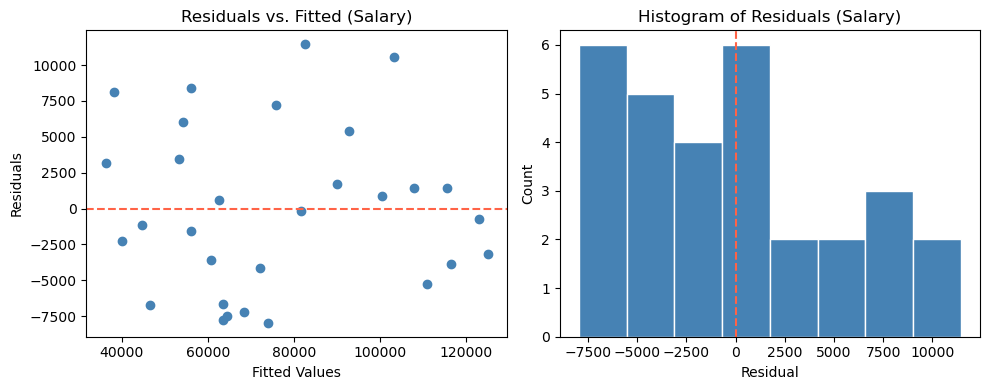

In [27]:
#TASK6

salary['predicted'] = model.predict(X)
salary['residual'] = salary['Salary'] - salary['predicted']

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(salary['predicted'], salary['residual'], color='steelblue')
plt.axhline(0, color='tomato', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted (Salary)')

plt.subplot(1, 2, 2)
plt.hist(salary['residual'], bins=8, color='steelblue',
         edgecolor='white')
plt.axvline(0, color='tomato', linestyle='--')
plt.xlabel('Residual')
plt.ylabel('Count')
plt.title('Histogram of Residuals (Salary)')

plt.tight_layout()
plt.show()

# Very slight fan at the beginning and tightens towards the end, but mostly evenly spaced
# Slightly skewed to the left, with some larger humps

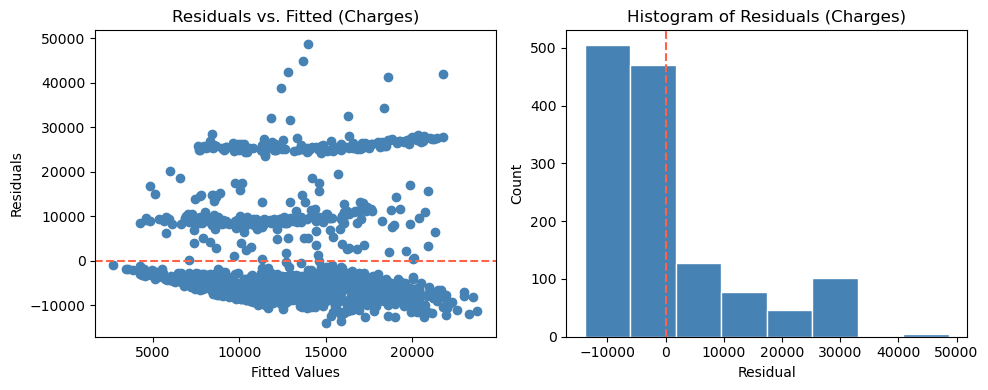

In [28]:
#TASK7

insurance['predicted'] = model2.predict(X2)
insurance['residual'] = insurance['charges'] - insurance['predicted']

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(insurance['predicted'], insurance['residual'], color='steelblue')
plt.axhline(0, color='tomato', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted (Charges)')

plt.subplot(1, 2, 2)
plt.hist(insurance['residual'], bins=8, color='steelblue',
         edgecolor='white')
plt.axvline(0, color='tomato', linestyle='--')
plt.xlabel('Residual')
plt.ylabel('Count')
plt.title('Histogram of Residuals (Charges)')

plt.tight_layout()
plt.show()

# Salary looks healthier because the spread of residuals is more even. The charges plot has a weird shape
# The range of values for charges is extremely high, the highest values going up to 50,000

Text(0.5, 1.0, 'Children vs. Charges')

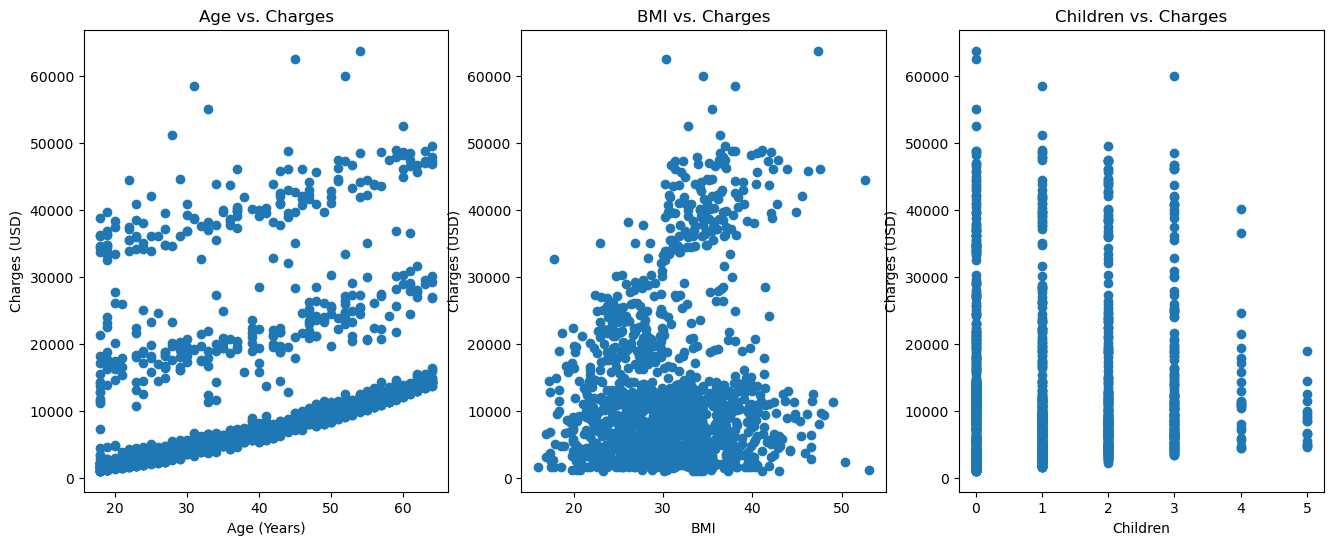

In [29]:
#TASK8

plt.figure(figsize=(16, 6))

plt.subplot(1, 3, 1)
plt.scatter(insurance['age'], insurance['charges'])
plt.xlabel('Age (Years)')
plt.ylabel('Charges (USD)')
plt.title('Age vs. Charges')

plt.subplot(1, 3, 2)
plt.scatter(insurance['bmi'], insurance['charges'])
plt.xlabel('BMI')
plt.ylabel('Charges (USD)')
plt.title('BMI vs. Charges')

plt.subplot(1, 3, 3)
plt.scatter(insurance['children'], insurance['charges'])
plt.xlabel('Children')
plt.ylabel('Charges (USD)')
plt.title('Children vs. Charges')

# 

In [34]:
#TASK9

insurance['smoker'] = insurance['smoker'].replace({'yes': 1, 'no': 0})

X3 = insurance[['age', 'bmi', 'children', 'smoker']]
y3 = insurance['charges']

model3 = LinearRegression()
model3.fit(X3,y3)

print(f"Intercept: {model3.intercept_:.2f}")
print("Coefficients:")
for name, coef in zip(X3.columns, model3.coef_):
    print(f"    {name}: {coef:.2f}")
print(" ")
print(f"Task 5 Intercept: {model2.intercept_:.2f}")
print("Task 5 Coefficients:")
for name, coef in zip(X2.columns, model2.coef_):
    print(f"    {name}: {coef:.2f}")

Intercept: -12102.77
Coefficients:
    age: 257.85
    bmi: 321.85
    children: 473.50
    smoker: 23811.40
 
Task 5 Intercept: -6916.24
Task 5 Coefficients:
    age: 239.99
    bmi: 332.08
    children: 542.86


-  All the coefficients went up except age, which went down slightly. Smoker is drastically higher than all others. 
-  Smoking makes a big impact on charges.
-  This is a health insurance data set. Smoking is a lifestyle choice that affects health in a negative way increasing risk to the company if coverage is provided. 

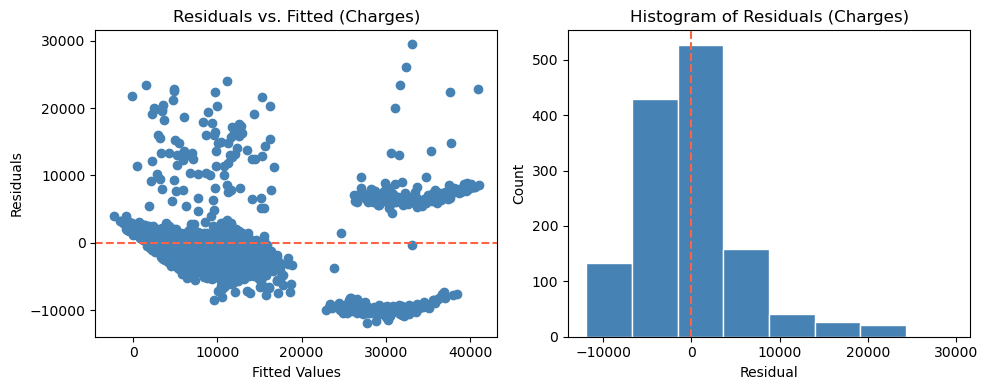

In [32]:
insurance['predicted'] = model3.predict(X3)
insurance['residual'] = insurance['charges'] - insurance['predicted']

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(insurance['predicted'], insurance['residual'], color='steelblue')
plt.axhline(0, color='tomato', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted (Charges)')

plt.subplot(1, 2, 2)
plt.hist(insurance['residual'], bins=8, color='steelblue',
         edgecolor='white')
plt.axvline(0, color='tomato', linestyle='--')
plt.xlabel('Residual')
plt.ylabel('Count')
plt.title('Histogram of Residuals (Charges)')

plt.tight_layout()
plt.show()


In [35]:
insurance.head()

,age,sex,bmi,children,smoker,region,charges,predicted,residual
0,19,female,27.900,0,1,southwest,16884.92400,25587.425249,-8702.501249
1,18,male,33.770,1,0,southeast,1725.55230,3880.945945,-2155.393645
2,28,male,33.000,3,0,southeast,4449.46200,7158.620069,-2709.158069
3,33,male,22.705,0,0,northwest,21984.47061,3713.900470,18270.570140
4,32,male,28.880,0,0,northwest,3866.85520,5443.483373,-1576.628173


In [68]:
insurance['region'] = insurance['region'].replace({'southwest': 1, 'northwest': 4, 'southeast': 2, 'northeast': 3})
insurance['sex'] = insurance['sex'].replace({'female':1 , 'male': 2})
insurance.head()

,age,sex,bmi,children,smoker,region,charges,predicted,residual
0,19,1,27.900,0,1,1,16884.92400,25308.656371,-8423.732371
1,18,2,33.770,1,0,3,1725.55230,3924.809483,-2199.257183
2,28,2,33.000,3,0,3,4449.46200,7217.723692,-2768.261692
3,33,2,22.705,0,0,2,21984.47061,3530.963475,18453.507135
4,32,2,28.880,0,0,2,3866.85520,5262.635749,-1395.780549


In [69]:
X4 = insurance[['age', 'bmi', 'children', 'smoker', 'region','sex']]
y4 = insurance['charges']

model4 = LinearRegression()
model4.fit(X4,y4)

print(f"model 4 Intercept: {model3.intercept_:.2f}")
print("model 4 Coefficients:")
for name, coef in zip(X4.columns, model4.coef_):
    print(f"    {name}: {coef:.2f}")
print(" ")
print(f"model 3 Intercept: {model3.intercept_:.2f}")
print("model 3 Coefficients:")
for name, coef in zip(X3.columns, model3.coef_):
    print(f"    {name}: {coef:.2f}")
print(" ")
print(f"Task 5 Intercept: {model2.intercept_:.2f}")
print("Task 5 Coefficients:")
for name, coef in zip(X2.columns, model2.coef_):
    print(f"    {name}: {coef:.2f}")



model 4 Intercept: -12102.77
model 4 Coefficients:
    age: 257.81
    bmi: 322.18
    children: 481.45
    smoker: 23797.55
    region: 214.60
    sex: -130.34
 
model 3 Intercept: -12102.77
model 3 Coefficients:
    age: 257.85
    bmi: 321.85
    children: 473.50
    smoker: 23811.40
 
Task 5 Intercept: -6916.24
Task 5 Coefficients:
    age: 239.99
    bmi: 332.08
    children: 542.86


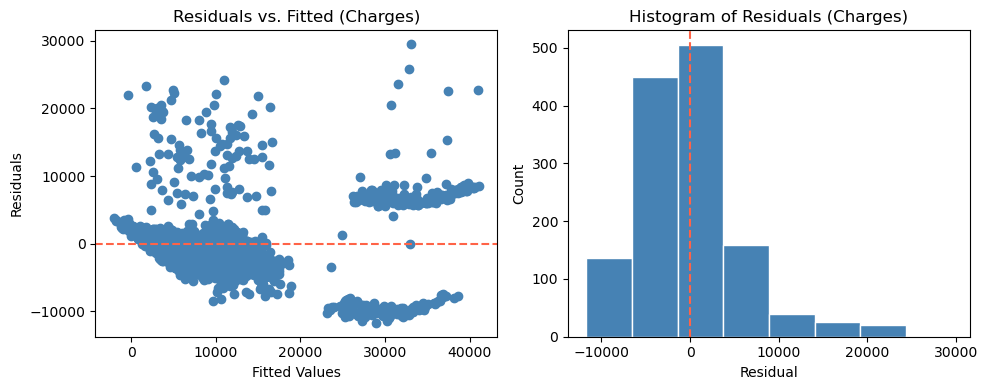

In [65]:
insurance['predicted'] = model4.predict(X4)
insurance['residual'] = insurance['charges'] - insurance['predicted']

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.scatter(insurance['predicted'], insurance['residual'], color='steelblue')
plt.axhline(0, color='tomato', linestyle='--')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs. Fitted (Charges)')

plt.subplot(1, 2, 2)
plt.hist(insurance['residual'], bins=8, color='steelblue',
         edgecolor='white')
plt.axvline(0, color='tomato', linestyle='--')
plt.xlabel('Residual')
plt.ylabel('Count')
plt.title('Histogram of Residuals (Charges)')

plt.tight_layout()
plt.show()